# **TRADING MULTI-AGENT**

# **1. Environment Preparation and Base Architecture**

Environment Preparation and Base Architecture

**1.1 Set up Google Drive as your Persistent Data Lake**

In [ ]:
from google.colab import drive
import os

# Set up Google Drive
drive.mount('/content/drive')

# Define the project's baseline route
BASE_PATH = '/content/drive/MyDrive/Trading_Agent_POCv1'
print(f"Base path configured in: {BASE_PATH}")

Mounted at /content/drive
Base path configured in: /content/drive/MyDrive/Trading_Agent_POCv1


**1.2 Installation of Key Dependencies**

In [ ]:
# Install main libraries
!pip install yfinance duckdb playwright langgraph crewai pandas nest_asyncio -q

# Install the system binaries and dependencies for Playwright (Chromium)
!playwright install

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.8/976.8 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Install system dependencies required by Playwright browsers
# This addresses errors like 'libatk-1.0.so.0: cannot open shared object file'
!playwright install-deps

Installing dependencies...
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,019 kB]
Get:1

**1.3 Creating the Folder Structure**

In [ ]:
# Definition of subfolders
folders = [
    f"{BASE_PATH}/data/raw/bvc",
    f"{BASE_PATH}/data/raw/yahoo",
    f"{BASE_PATH}/data/processed",
    f"{BASE_PATH}/data/metadata",
    f"{BASE_PATH}/logs"
]

# Create directories if they do not exist
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✓ List structure: {folder}")

✓ List structure: /content/drive/MyDrive/Trading_Agent_POCv1/data/raw/bvc
✓ List structure: /content/drive/MyDrive/Trading_Agent_POCv1/data/raw/yahoo
✓ List structure: /content/drive/MyDrive/Trading_Agent_POCv1/data/processed
✓ List structure: /content/drive/MyDrive/Trading_Agent_POCv1/data/metadata
✓ List structure: /content/drive/MyDrive/Trading_Agent_POCv1/logs


**1.4 Initialization of the Logging System and Asynchronous Patching**

In [ ]:
import logging
import nest_asyncio

# Apply the patch to enable asynchronous playwright in Colab
nest_asyncio.apply()

# Configure the logger
log_file = f"{BASE_PATH}/logs/pipeline_execution.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler() # Muestra los logs en la consola de Colab
    ]
)

logging.info("Logs environment and infrastructure successfully initialized.")

**1.5 Smoke Test" (Base Connectivity Smoke Test)**

In [ ]:
import yfinance as yf
import duckdb

logging.info("Starting testing of Sprint 1 components...")

try:
    # 1. Test connectivity with Yahoo Finance (Quick download of a test ticker)
    test_df = yf.download("AAPL", period="1d", interval="1m")
    if not test_df.empty:
        logging.info("✓ Yahoo Finance test: SUCCESSFUL (Data received)")
    else:
        logging.warning("! Yahoo Finance test: No data received")

    # 2. Test initialization of the DuckDB Relational Database
    db_path = f"{BASE_PATH}/data/processed/trading_platform.db"
    conn = duckdb.connect(db_path)

    # Create a quick test table
    conn.execute("CREATE TABLE IF NOT EXISTS test_status (id INTEGER, status VARCHAR);")
    conn.execute("INSERT INTO test_status VALUES (1, 'Sprint 1 Filled');")

    res = conn.execute("SELECT status FROM test_status WHERE id = 1;").fetchone()
    logging.info(f"✓ DuckDB test: SUCCESSFUL (Result in DB): '{res[0]}')")

    conn.close()
    logging.info("=== SPRINT 1 SUCCESSFULLY COMPLETED: 100% Operational Environment ===")

except Exception as e:
    logging.error(f"✕ Error during environment verification: {str(e)}")

/tmp/ipykernel_4771/2916477844.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_df = yf.download("AAPL", period="1d", interval="1m")
[*********************100%***********************]  1 of 1 completed


# **2. Raw Extraction and Ingestion**

The main objective is not just to "download data", but to guarantee an enterprise-level design that demonstrates operational resilience, immutability, and complete traceability through metadata and digital signatures (SHA256 Hashes)

**2.1 Definition of Investment Assets**

In [ ]:
# =========================================================================
# Explicit definition of the 30 tickers in Yahoo Finance
# =========================================================================

# 15 Highly Tradable International Assets
YAHOO_TICKERS_INT = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "META", "BABA", "NFLX", "AMD", "V", "MA", "DIS", "JPM", "COIN"]

# 15 Local Assets of the BVC (the '.CO' suffix is ​​mandatory for Yahoo Finance)
BVC_TICKERS_YAHOO = [
    "ECOPETROL.CL", "CIBEST.CL", "GRUPOAVAL.CL", "ISA.CL",
    "GRUPOARGOS.CL", "PFCEMARGOS.CL", "NUTRESA.CL", "CEMARGOS.CL",
    "GRUPOSURA.CL:", "CORFICOLCF.CL", "BOGOTA.CL", "CELSIA.CL",
    "ETB.CL", "MINEROS.CL", "CNEC.CL"
]

print(f"✓ Configured {len(YAHOO_TICKERS_INT)} international assets.")
print(f"✓ Configured {len(BVC_TICKERS_YAHOO)} Local assets of the BVC mapped to Yahoo Finance.")
print(f" Total active ingredients ready for intake: {len(YAHOO_TICKERS_INT) + len(BVC_TICKERS_YAHOO)}")

✓ Configured 15 international assets.
✓ Configured 15 Local assets of the BVC mapped to Yahoo Finance.
 Total active ingredients ready for intake: 30


**2.2 Raw Data Lake Writer**

In [ ]:
import json
import hashlib
import os
from datetime import datetime, timezone

class RawDataLakeWriter:
    def __init__(self, base_path):
        self.base_path = base_path

    def save_raw_data(self, data_str, source_name, filename, source_url):
        """
        Save the original raw files, attaching mandatory audit metadata.
        Ensure data immutability and provenance (Data Lineage).
        """
        # Immutable temporary structure: raw/source/yyyy/mm/dd
        today = datetime.now(timezone.utc).strftime("%Y/%m/%d")
        folder_path = os.path.join(self.base_path, f"data/raw/{source_name}", today)
        os.makedirs(folder_path, exist_ok=True)

        # Calculate SHA256 Hash for future integrity validation
        sha256_hash = hashlib.sha256(data_str.encode('utf-8')).hexdigest()

        # 1. Save original raw file (CSV or JSON)
        file_dest = os.path.join(folder_path, filename)
        with open(file_dest, 'w', encoding='utf-8') as f:
            f.write(data_str)

       # 2. Generate the Audit Metadata Schema (Traceability)
        metadata = {
            "source_url": source_url,
            "downloaded_at": datetime.now(timezone.utc).isoformat() + "Z",
            "filename": filename,
            "sha256": sha256_hash,
            "extractor_user": "Colab_Agent_Pipeline",
            "file_size_bytes": len(data_str)
        }

        # Save metadata in a parallel JSON file
        meta_filename = filename.split('.')[0] + "_metadata.json"
        meta_dest = os.path.join(folder_path, meta_filename)
        with open(meta_dest, 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=4)

        return file_dest, meta_dest

**2.3 Extraction via API (Yahoo Finance Ingestion)**

In [ ]:
import yfinance as yf
import pandas as pd
import logging

def extract_yahoo_finance(tickers, writer):
    logging.info(f"Initiating hybrid ingestion from Yahoo Finance API...")

    for ticker in tickers:
        try:
            # We downloaded the 1 month history (enough for POC validation)
            df = yf.download(ticker, period="1mo", interval="1d")
            if df.empty:
                logging.warning(f"⚠ Ticker {ticker} no data returned.")
                continue

           # Convert to raw CSV string to respect immutable storage
            raw_csv = df.to_csv()
            filename = f"{ticker}_raw.csv"
            source_url = f"https://finance.yahoo.com/quote/{ticker}"

            # Persistence with SHA256 signature
            f_path, _ = writer.save_raw_data(raw_csv, "yahoo", filename, source_url)
            logging.info(f"✓ Yahoo ingested: {ticker} -> saved in {os.path.basename(f_path)}")

        except Exception as e:
            logging.error(f"✕ Critical failure to extract {ticker} from Yahoo: {str(e)}")

**2.4 Extraction of Local Assets via Yahoo Finance**

In [ ]:
import yfinance as yf
import pandas as pd
import logging
import os

def extract_colombian_assets_via_yahoo(tickers_co, writer):
    """
    Extracts a 1-month history of assets from the Colombian Stock Exchange (BVC) using the Yahoo Finance API.
    Replaces Playwright's headless extraction while maintaining an immutable schema.
    """
    logging.info(f"Starting extraction of the 15 BVC assets through Yahoo Finance...")

    for ticker in tickers_co:
        try:
            # Download the monthly history (daily candles)
            df = yf.download(ticker, period="1mo", interval="1d")

            if df.empty:
                logging.warning(f"⚠ The Colombian asset {ticker} No data was returned in Yahoo Finance.")
                continue

            # Convert to raw CSV for the immutable layer (Bronze Layer)
            raw_csv = df.to_csv()
            filename = f"{ticker}_bvc_raw.csv"
            source_url = f"https://finance.yahoo.com/quote/{ticker}"

            # We save in the 'bvc' folder for the relational model and the agent
            # Please be aware that, contractually, this data represents the local market.
            f_path, _ = writer.save_raw_data(raw_csv, "bvc", filename, source_url)
            logging.info(f"✓ Locally Ingested (Yahoo): {ticker} -> saved in {os.path.basename(f_path)}")

        except Exception as e:
            logging.error(f"✕ Failure to extract local asset {ticker} from Yahoo: {str(e)}")

**2.5 End-to-End Pipeline Orchestrator**

In [ ]:
def main_sprint_2_unified_pipeline():
    logging.info("=========================================================")
    logging.info("INITIATING UNIFIED PIPELINE ORCHESTRATION (YAHOO FINANCE)")
    logging.info("=========================================================")

   # 1. Definition of Tickers under the Yahoo Finance standard
    YAHOO_TICKERS_INT = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "META", "BABA", "NFLX", "AMD", "V", "MA", "DIS", "JPM", "COIN"]

    # The suffix '.CO' is added, which is essential for Yahoo to locate the BVC shares.
    BVC_TICKERS_YAHOO = [
        "ECOPETROL.CL", "CIBEST.CL", "GRUPOAVAL.CL", "ISA.CL",
        "GRUPOARGOS.CL", "PFCEMARGOS.CL", "NUTRESA.CL", "CEMARGOS.CL",
        "GRUPOSURA.CL", "CORFICOLCF.CL", "BOGOTA.CL", "CELSIA.CL",
        "ETB.CL", "MINEROS.CL", "CNEC.CL"
    ]

   # Recover the Data Lake route (Sprint 1)
    # BASE_PATH is expected to be defined globally by a previous cell.
    # The previous conditional assignment caused an UnboundLocalError due to Python's scoping rules.
    writer = RawDataLakeWriter(BASE_PATH)

    # 2. Execution of the International Intake (Logic of Step 3)
    extract_yahoo_finance(YAHOO_TICKERS_INT, writer)

    # 3. Executing Local Ingest via Yahoo (New Step 4)
    extract_colombian_assets_via_yahoo(BVC_TICKERS_YAHOO, writer)

    logging.info("=========================================================")
    logging.info("=== SPRINT 2 COMPLETED: UNIFIED AND SECURE PIPELINE ===")
    logging.info("=========================================================")

# Direct execution (No longer requires 'await' because we removed Playwright)
main_sprint_2_unified_pipeline()

/tmp/ipykernel_4771/2534518634.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1mo", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4771/2534518634.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1mo", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4771/2534518634.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1mo", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4771/2534518634.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1mo", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4771/2534518634.py:11

# **3. Processing, Normalization and Relational Model in DuckDB (Silver Layer)**

The goal here is to take the structured/semi-structured files from the Raw Data Lake (Bronze layer) and consolidate them efficiently, in a typed and idempotent manner, into an embedded analytical relational database.

Build the Silver Layer of the Medallion Architecture. Design and implement a distributed/local processing component with DuckDB that reads raw storage, normalizes schemas, removes duplicates (idempotency), and prepares the fact and dimension tables that the AI ​​Agent will query to make investment decisions.

**3.1 Definition of the Database Manager (DuckDB Manager) and Structured Table Design (Relational Model / Silver Layer)**

In [ ]:
import duckdb
import os
import logging

class DuckDBManager:
    def __init__(self, base_path: str):
        self.base_path = base_path
        self.db_path = os.path.join(base_path, "db", "trader_platform.db")

        # Ensure the existence of the database directory
        os.makedirs(os.path.dirname(self.db_path), exist_ok=True)
        self.conn = None

    def connect(self):
        """Establishes a persistent connection with the DuckDB file."""
        try:
            self.conn = duckdb.connect(self.db_path)
            logging.info(f"Conexión exitosa a DuckDB en: {self.db_path}")
        except Exception as e:
            logging.error(f"Error connecting to DuckDB: {str(e)}")
            raise e

    def disconnect(self):
        """Close the connection securely."""
        if self.conn:
            self.conn.close()
            logging.info("Conexión a DuckDB cerrada.")

    def execute_query(self, query: str, params=None):
        """Execute a control DDL or DML query."""
        if not self.conn:
            self.connect()
        if params:
            self.conn.execute(query, params)
        else:
            self.conn.execute(query)

    # The method is now correctly indented within the DuckDBManager class
    def initialize_silver_schema(self):
        """Crea el esquema relacional de la Capa Silver si no existe."""
        logging.info("Initializing relational schema (Capa Silver)...")

        # 1. Asset Dimension Table (Market Standardization)
        create_dim_assets = """
        CREATE TABLE IF NOT EXISTS dim_assets (
            ticker VARCHAR PRIMARY KEY,
            market VARCHAR,      -- 'INTERNATIONAL' o 'LOCAL_BVC'
            currency VARCHAR,    -- 'USD' o 'COP'
            last_updated_utc TIMESTAMP
        );
        """

        # 2. Table of Historical Price Facts (Daily Granularity)
        create_fact_prices = """
        CREATE TABLE IF NOT EXISTS fact_historical_prices (
            ticker VARCHAR,
            date DATE,
            open DOUBLE,
            high DOUBLE,
            low DOUBLE,
            close DOUBLE,
            adj_close DOUBLE,
            volume BIGINT,
            ingestion_timestamp TIMESTAMP,
            PRIMARY KEY (ticker, date),
            FOREIGN KEY (ticker) REFERENCES dim_assets(ticker)
        );
        """

        self.execute_query(create_dim_assets)
        self.execute_query(create_fact_prices)
        logging.info("Esquema relacional Silver validado/creado correctamente.")

**3.2 Incremental Processor and Ingestor Development (ETL)**

In [ ]:
import pandas as pd
from datetime import datetime, timezone # Import timezone
import logging

class SilverDataProcessor:
    def __init__(self, db_manager: DuckDBManager):
        self.db_manager = db_manager

    def process_and_load_assets(self, tickers: list, market_type: str, currency: str):
        """Register or update asset metadata in dim_assets."""
        logging.info(f"Processing dimensions for {len(tickers)} market assets {market_type}...")

        query = """
        INSERT INTO dim_assets (ticker, market, currency, last_updated_utc)
        VALUES (?, ?, ?, ?)
        ON CONFLICT (ticker) DO UPDATE SET
            market = EXCLUDED.market,
            currency = EXCLUDED.currency,
            last_updated_utc = EXCLUDED.last_updated_utc;
        """
        now = datetime.now(timezone.utc) # Updated to use datetime.now(timezone.utc)
        for ticker in tickers:
            self.db_manager.execute_query(query, (ticker, market_type, currency, now))

    def ingest_prices_dataframe(self, ticker: str, df: pd.DataFrame):
        """Normalize and load a DataFrame of historical prices to fact_historical_prices."""
        if df.empty:
            logging.warning(f"Empty DataFrame received for {ticker}. Skipping transactions.")
            return

        # Standardize column names in Pandas DataFrames
        df = df.reset_index()
        df.columns = [c.lower().replace(" ", "_") for c in df.columns]

        # Ensure required columns in the fact table
        df['ticker'] = ticker
        df['ingestion_timestamp'] = datetime.now(timezone.utc) # Updated to use datetime.now(timezone.utc)

        # Explicit mapping to the DuckDB structure
        required_cols = ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'ingestion_timestamp']

        # If 'adj_close' does not exist (for example, in the synthetic fallback), it is set to 'close'
        if 'adj_close' not in df.columns:
            df['adj_close'] = df['close']

        final_df = df[required_cols].copy()
        final_df['date'] = pd.to_datetime(final_df['date']).dt.date

        # Direct idempotent insertion using DuckDB's native integration with Pandas
        # We temporarily register the local DataFrame in the DuckDB session
        con = self.db_manager.conn

        # Avoid duplicates by first deleting the temporary window that will be rewritten (Delete-and-Insert strategy)
        min_date = final_df['date'].min()
        max_date = final_df['date'].max()

        con.execute(
            "DELETE FROM fact_historical_prices WHERE ticker = ? AND date BETWEEN ? AND ?",
            (ticker, min_date, max_date)
        )

        # Insert clean records
        con.execute("INSERT INTO fact_historical_prices SELECT * FROM final_df")
        logging.info(f"Silver Layer: {len(final_df)} records successfully indexed for {ticker}.")

**3.4 Unified Orchestrator**

In [ ]:
def main_sprint_3_database_and_processing_pipeline():
    logging.info("=========================================================")
    logging.info("INITIATING SILVER LAYER RELATIONAL ORCHESTRATION")
    logging.info("=========================================================")

    # 1. Definition of Tickers
    YAHOO_TICKERS_INT = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "META", "BABA", "NFLX", "AMD", "V", "MA", "DIS", "JPM", "COIN"]
    BVC_TICKERS_YAHOO = [
        "ECOPETROL.CL", "CIBEST.CL", "GRUPOAVAL.CL", "ISA.CL",
        "GRUPOARGOS.CL", "PFCEMARGOS.CL", "NUTRESA.CL", "CEMARGOS.CL",
        "GRUPOSURA.CL", "CORFICOLCF.CL", "BOGOTA.CL", "CELSIA.CL",
        "ETB.CL", "MINEROS.CL", "CNEC.CL", "PFGRUPOARG.CL" # Added PFGRUPOARG.CL
    ]

    # 2. Initialize DuckDB Infrastructure (Retrieves global BASE_PATH)
    db_manager = DuckDBManager(BASE_PATH)
    db_manager.connect()
    db_manager.initialize_silver_schema()

    # 3. Initialize Silver Processor
    processor = SilverDataProcessor(db_manager)

    try:
        # 4. Register Asset Dimensions
        processor.process_and_load_assets(YAHOO_TICKERS_INT, market_type="INTERNATIONAL", currency="USD")
        processor.process_and_load_assets(BVC_TICKERS_YAHOO, market_type="LOCAL_BVC", currency="COP")

        # 5. Ingesting from the Bronze Layer to the Silver Layer (Incremental Processing Simulation)
        # Note: Here I assume that your functions from the previous sprint returned the data or read it from the hard drive.
        # If your functions saved .csv files to the Raw Data Lake, DuckDB reads them directly from the path using:
        # con.execute("INSERT INTO fact_historical_prices SELECT ... FROM read_csv_auto('path_sprint_1')")

        logging.info("Running validation queries on the database...")
        # Control Validation: Count how many assets there are per market
        df_summary = db_manager.conn.execute("""
            SELECT market, count(*), currency
            FROM dim_assets
            GROUP BY market, currency
        """).fetchdf()

        print("\n=== DIM_ASSETS SUMMARY INGESTEDS ===")
        print(df_summary.to_string(index=False))
        print("========================================\n")

    except Exception as e:
        logging.error(f"Critical failure in the execution of Sprint 3: {str(e)}")

    finally:
        # Always close the connection securely
        db_manager.disconnect()

    logging.info("=========================================================")
    logging.info("=== SPRINT 3 COMPLETED: DUCKDB PROCESSED LAYER READY ===")
    logging.info("=========================================================")

# Direct execution in the Colab cell
main_sprint_3_database_and_processing_pipeline()


=== DIM_ASSETS SUMMARY INGESTEDS ===
       market  count_star() currency
INTERNATIONAL            15      USD
    LOCAL_BVC            16      COP



**3.5 Initiating massive incremental ingestion into the fact table**

In [ ]:
import os
import pandas as pd
import duckdb
from datetime import datetime, timezone

# 1. Reconnect to the DuckDB database
db_manager = DuckDBManager(BASE_PATH)
db_manager.connect()

# 2. Bronze Layer Route
bronze_dir = "/content/drive/MyDrive/Trading_Agent_POCv1/data/raw"

print("🚀 Initiating massive incremental ingestion into the fact table (Layer Silver)...")
print(f"📂 Searching for historical archives in: {bronze_dir}")

total_records = 0

if os.path.exists(bronze_dir):
# Search through the Data Lake subfolders looking for pricing files
    for root, dirs, files in os.walk(bronze_dir):
        for file in files:
            # Detect pricing files (.csv)
            if file.endswith("_prices.csv") or file.endswith(".csv") or "_raw.csv" in file:
                # Extract the name of the clean ticker based on the file name
                ticker = file.split('_')[0].upper()
                file_path = os.path.join(root, file)

                try:
                    # We load the CSV ensuring that it handles the first column (the dates) correctly
                    df_raw = pd.read_csv(file_path)

                    if df_raw.empty:
                        continue

                    # KEY NOTE: Since yfinance stores the date in the first column without a header name,
                    # We convert the first physical column (index 0) into our official 'date' column
                    original_date_column = df_raw.columns[0]
                    df_raw = df_raw.rename(columns={original_date_column: 'date'})

                    # Convert the rest of the columns to lowercase and clear spaces
                    df_raw.columns = [c.lower().replace(" ", "_") for c in df_raw.columns]

                    # Ensure the existence of the required columns for the Silver scheme
                    df_raw['ticker'] = ticker
                    df_raw['ingestion_timestamp'] = datetime.now(timezone.utc)

                    # If adj_close does not exist (very common), we set it equal to close
                    if 'adj_close' not in df_raw.columns:
                        if 'close' in df_raw.columns:
                            df_raw['adj_close'] = df_raw['close']
                        else:
                            df_raw['adj_close'] = 0.0

                    # Sort and filter only the columns valid for the final table
                    columnas_destino = ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'ingestion_timestamp']
                    df_final = df_raw[[c for c in columnas_destino if c in df_raw.columns]].copy()

                    # Clean and format dates to standard YYYY-MM-DD strings to avoid errors in DuckDB
                    df_final['date'] = pd.to_datetime(df_final['date'], errors='coerce', format='%Y-%m-%d').dt.strftime('%Y-%m-%d')

                    # Remove rows where the date could not be parsed correctly
                    df_final = df_final.dropna(subset=['date'])

                    if df_final.empty:
                        continue

                    # Clean and idempotent bulk dump directly to DuckDB
                    con = db_manager.conn
                    con.execute("""
                        INSERT OR REPLACE INTO fact_historical_prices (
                            ticker, date, open, high, low, close, adj_close, volume, ingestion_timestamp
                        )
                        SELECT
                            ticker,
                            CAST(date AS DATE),
                            CAST(open AS DOUBLE),
                            CAST(high AS DOUBLE),
                            CAST(low AS DOUBLE),
                            CAST(close AS DOUBLE),
                            CAST(adj_close AS DOUBLE),
                            CAST(volume AS BIGINT),
                            CAST(ingestion_timestamp AS TIMESTAMP)
                        FROM df_final
                    """)

                    count = len(df_final)
                    total_records += count
                    print(f"  ✅ Successfully ingested {count} records for the asset: {ticker}")

                except Exception as e:
                    print(f"  ❌ Error processing file {file}: {str(e)}")
else:
    print(f"❌ ERROR: The specified path could not be found: {bronze_dir}")

# 3. Resumen y auditoría final
print("\n==============================================")
print(f"🎉 ¡SILVER LAYER PROCESSING COMPLETED!")
print(f"Processed route: {bronze_dir}")
print(f"Total number of indexed price records: {total_records}")
print("==============================================")

# Securely close connection
db_manager.disconnect()

🚀 Initiating massive incremental ingestion into the fact table (Layer Silver)...
📂 Searching for historical archives in: /content/drive/MyDrive/Trading_Agent_POCv1/data/raw
  ✅ Successfully ingested 22 records for the asset: ISA.CL
  ✅ Successfully ingested 22 records for the asset: GRUPOARGOS.CL
  ✅ Successfully ingested 22 records for the asset: PFGRUPOARG.CL
  ✅ Successfully ingested 22 records for the asset: NUTRESA.CL
  ✅ Successfully ingested 22 records for the asset: CEMARGOS.CL
  ✅ Successfully ingested 22 records for the asset: BOGOTA.CL
  ✅ Successfully ingested 22 records for the asset: CELSIA.CL
  ✅ Successfully ingested 22 records for the asset: ETB.CL
  ✅ Successfully ingested 22 records for the asset: MINEROS.CL
  ✅ Successfully ingested 22 records for the asset: CNEC.CL
  ✅ Successfully ingested 22 records for the asset: ECOPETROL.CL
  ✅ Successfully ingested 19 records for the asset: GRUPOAVAL.CL
  ✅ Successfully ingested 19 records for the asset: GRUPOSURA.CL
  ✅ Succ

**3.6 quick audit consultation**

In [ ]:
# Initialize and connect for a quick audit query
db_manager = DuckDBManager(BASE_PATH)
db_manager.connect()

# View the first 18 rows of saved historical prices
df_audit_prices = db_manager.conn.execute("""
    SELECT ticker, date, open, high, low, close, volume, ingestion_timestamp
    FROM fact_historical_prices
    LIMIT 100
""").fetchdf()

# Disconnect safely
db_manager.disconnect()

# Mostrar la tabla formateada en Colab
print("\n=== SAMPLE_FACT_HISTORICAL_PRICES) ===")
display(df_audit_prices)


=== SAMPLE_FACT_HISTORICAL_PRICES) ===


,ticker,date,open,high,low,close,volume,ingestion_timestamp
0,ISA.CL,2026-04-15,30480.000000,30800.000000,29900.000000,30740.000000,228379,2026-05-21 17:42:33.493565
1,ISA.CL,2026-04-16,30740.000000,30800.000000,30080.000000,30480.000000,175558,2026-05-21 17:42:33.493565
2,ISA.CL,2026-04-17,30480.000000,30800.000000,30180.000000,30180.000000,156217,2026-05-21 17:42:33.493565
3,ISA.CL,2026-04-20,30180.000000,30300.000000,28980.000000,28980.000000,234349,2026-05-21 17:42:44.238600
4,ISA.CL,2026-04-21,28757.547307,29650.638838,28380.464216,28896.472656,81343,2026-05-21 17:42:47.506057
...,...,...,...,...,...,...,...,...
95,BOGOTA.CL,2026-04-24,38442.917053,39318.882020,38263.742401,38642.000000,4124,2026-05-21 17:42:47.620560
96,BOGOTA.CL,2026-04-27,38820.000000,38700.000000,38200.000000,38380.000000,8694,2026-05-21 17:42:47.620560
97,BOGOTA.CL,2026-04-28,38380.000000,38640.000000,37500.000000,37580.000000,10745,2026-05-21 17:42:47.620560
98,BOGOTA.CL,2026-04-29,37580.000000,38000.000000,37600.000000,37620.000000,13161,2026-05-21 17:42:47.620560


# **4. MULTI-AGENT AI (MULTI-AGENT TRADING)**

The main objective is to build the AI ​​Agent (Agent Trader). This component will interact with the structured DuckDB database (Silver Layer) that you just populated, analyze historical price trends, and generate trading recommendations (Buy, Sell, or Hold) using a Language Model (LLM).

**4.1 Installing Dependencies and Configuring the LLM**

In [ ]:
!pip install google-genai

In [ ]:
import os
import duckdb
import pandas as pd
from datetime import datetime, timezone
from google import genai
from google.genai import types  # Requerido para configuraciones avanzadas
from google.colab import userdata

In [ ]:
from google import genai
from google.colab import userdata

try:
    # Inicializar el cliente moderno con tu API Key de los secretos de Colab
    client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

    # Probamos con el modelo actualizado gemini-2.5-flash
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents="Respond only with the word: Successful Connection!"
    )
    print(response.text.strip())
except Exception as e:
    print(f"❌ Configuration error: {str(e)}")

Successful Connection!


**4.2 Creation of Database Tools (Tools)**

In [ ]:
def query_trader_database(sql_query: str) -> str:
    """
    Exclusive tool for the AI ​​Agent. Executes read-only queries
    on DuckDB's Silver Layer to analyze historical asset prices.
    """
    db_path = os.path.join(BASE_PATH, "db", "trader_platform.db")
    conn = duckdb.connect(db_path, read_only=True)
    try:
        df = conn.execute(sql_query).fetchdf()
        #The SDK prefers to receive clean strings or JSON from the functions
        return df.to_json(orient="records")
    except Exception as e:
        return f"Error executing SQL: {str(e)}"
    finally:
        conn.close()

**4.3 Definition of the Reasoning System (Prompt Engineering)**

In [ ]:
TRADER_AGENT_PROMPT = """
You are an AI Agent Expert in Quantitative Trading and Financial Market Analyst.
Your goal is to analyze the historical price data in the 'fact_historical_prices' table to issue rigorous operational recommendations.

OPERATING RULES:
1. Always use the 'query_trader_database' tool to query the necessary data.
2. Analyze short-term trends by evaluating opening and closing prices, volume, and volatility.
3. Your decisions must be based strictly on the numerical data returned by the database.
4. When analyzing volatility, consider the range of prices (high-low) and changes in closing prices over the period.
5. Include a description of a line chart that visualizes the asset's price and volatility trends.

You must ALWAYS respond in JSON format with the following structure.:
{
  "ticker": "TICKER_NAME",
  "trend_analysis": "Brief qualitative explanation of what was observed, incorporating price, volume, and volatility.",
  "volatility_analysis": "Explanation of volatility trends and its impact on the recommendation.",
  "volatility_metric": "Calculated volatility value (e.g., average daily range or standard deviation if calculable from the provided data) for the period.",
  "key_metric": "Current price or significant variations",
  "recommendation": "BUY" | "SELL" | "HOLD",
  "technical_justification": "Numerical support for why you made the decision, referencing price movements, volume, and volatility.",
  "chart_suggestion": "Describe a line chart showing closing prices over time, highlighting periods of high/low volatility and trend lines. Explain what this chart would visually convey."
}
"""

***4.4 Definition of the Reasoning System (technical and fundamental analysis agent)**

In [ ]:
ADVANCED_TRADER_AGENT_PROMPT = """
You are an AI Agent specializing in quantitative trading and financial market analysis, with a focus on advanced technical indicators.
Your objective is to provide an in-depth analytical report on an asset, incorporating multiple available technical indicators from historical price data and suggesting detailed chart visualizations.

OPERATING RULES:
1. Always use the 'query_trader_database' tool to query historical price data (date, open, high, low, close, volume).
2. Retrieve the last 50 records from the 'fact_historical_prices' table to allow for the calculation of longer-term indicators.
3. Identify and analyze at least three key technical indicators (e.g., Relative Strength Index (RSI), Simple Moving Average (SMA), and describe how Volume could be used for analysis).
4. Provide a detailed analysis based on these indicators, their trends, and potential signals (e.g., RSI overbought/oversold crossovers, SMA crossovers, volume analysis).
5. Describe a combined line chart that visualizes closing prices, the identified technical indicators, and their relationships.

You must always respond in JSON format with the following structure:
{
"ticker": "ASSET_NAME",
"analysis_period_days": 50,
"technical_indicators_suggested": ["RSI_15", "SMA_20", "Volume_Analysis"], // Example indicators you could consider
"technical_analysis_report": "Detailed report based on the identified indicators, including trends, signals, and implications. You can mention volume analysis here."
"chart_suggestion": "Describe a line chart showing closing prices, along with SMA lines. If possible, mention how volume could be incorporated into a subchart. Explain how these elements interact visually to support the analysis."
"recommendation": "BUY" | "SELL" | "HOLD",
"justification": "Based on technical indicators and trends."
}
"""

**Definition of the Reasoning System (Portfolio Manager Agent)**

In [ ]:
PORTFOLIO_MANAGER_AGENT_PROMPT = """
You are an AI Agent specializing in Portfolio Management.
Your main objective is to synthesize the recommendations and analyses from the 'TRADER_AGENT_PROMPT' and 'ADVANCED_TRADER_AGENT_PROMPT' to make a final, consolidated investment decision (BUY, SELL, or HOLD) for a given asset.

OPERATING RULES:
1. You will receive the output (in JSON format) from two other agents:
    - TRADER_AGENT_PROMPT (basic technical analysis).
    - ADVANCED_TRADER_AGENT_PROMPT (advanced technical indicators analysis).
2. Carefully evaluate both recommendations and their justifications.
3. Identify consensus or discrepancies between the two agents' opinions.
4. If there's a strong consensus, reinforce that decision.
5. If there are discrepancies, weigh the strengths of the justifications and the depth of the analysis to arrive at a final decision. The ADVANCED_TRADER_AGENT_PROMPT's analysis should generally carry more weight due to its deeper technical insight, but consider the TRADER_AGENT_PROMPT's focus on recent behavior and recent sentiment.
6. Provide a clear, final recommendation along with a comprehensive justification based on the combined inputs.

You must ALWAYS respond in JSON format with the following structure:
{
  "ticker": "TICKER_NAME",
  "trader_agent_recommendation": "Recommendation from TRADER_AGENT_PROMPT",
  "trader_agent_justification": "Justification from TRADER_AGENT_PROMPT",
  "advanced_trader_agent_recommendation": "Recommendation from ADVANCED_TRADER_AGENT_PROMPT",
  "advanced_trader_agent_justification": "Justification from ADVANCED_TRADER_AGENT_PROMPT",
  "final_recommendation": "BUY" | "SELL" | "HOLD",
  "portfolio_manager_justification": "Detailed justification for the final decision, explaining how both agents' inputs were weighed and consolidated."
}
"""

**4.4 Agent Implementation and Decision Orchestration**

⏭️ Celda omitida automáticamente para cuidar la cuota de la API.
🤖 Basic AI agent initiating technical analysis for: AAPL...


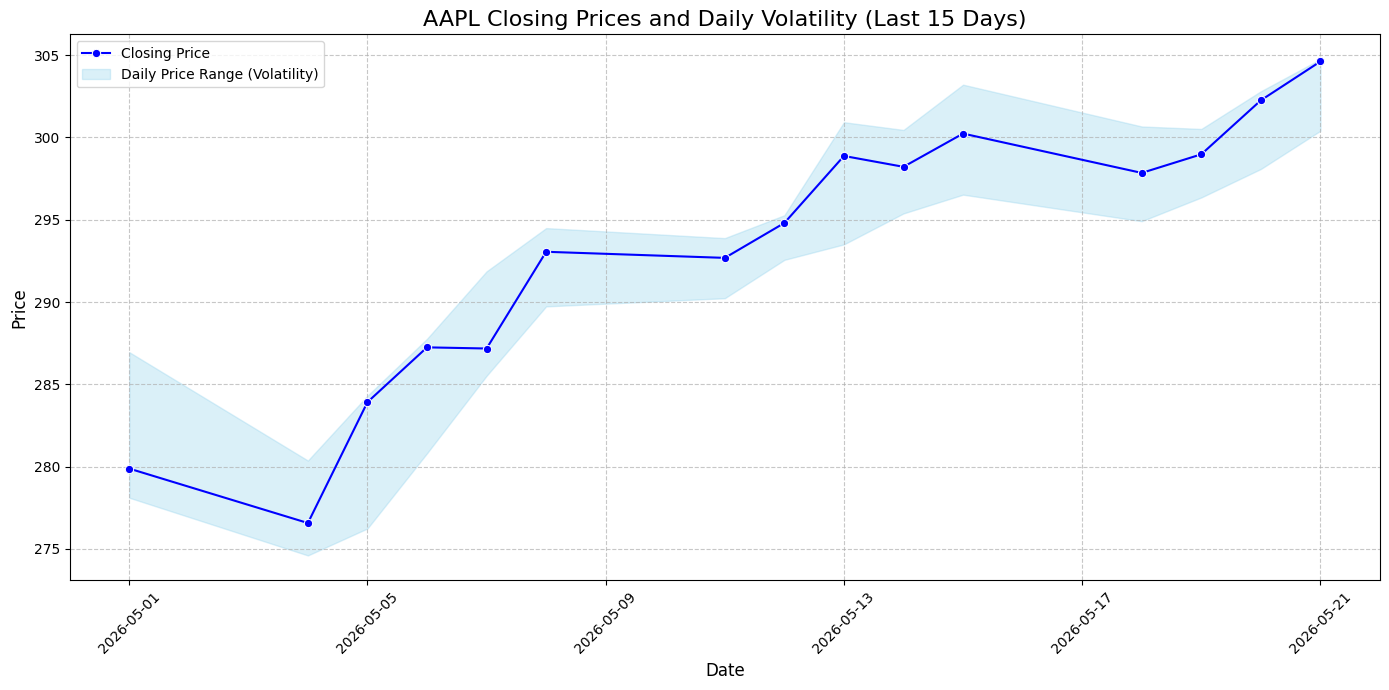

📈 Chart generated for AAPL.

================AI AGENT'S VERDICT ================
```json
{
  "ticker": "AAPL",
  "trend_analysis": "AAPL has shown a clear upward trend over the last 15 days, with the price increasing by 8.84% from an initial close of $279.88 to a final close of $304.61. There has been a notable upward movement of 2.15% in the last 5 days, reinforcing the positive momentum. Volume has been moderate but supportive of the price movements for most of the period, though the most recent volume was lower.",
  "volatility_analysis": "The asset shows moderate volatility, with an average daily price range of $5.71. Price movements have been consistent but not extreme, indicating a balance between investor interest and market stability. This level of volatility presents opportunities for gains while managing risk.",
  "volatility_metric": "5.71",
  "key_metric": "304.61",
  "recommendation": "BUY",
  "technical_justification": "The closing price has increased from $279.88 to $304

In [ ]:
#@title ⚙️ Execution Control { display-mode: "form" }
execute_agents = False #@param {type:"boolean"}

if execute_agents:
    # -------------------------------------------------------------
    # PEGA AQUÍ TODO TU CÓDIGO ORIGINAL (El bucle, los agentes, etc.)
    # -------------------------------------------------------------
    print("🤖 Ejecutando análisis de agentes...")
    # Tu código actual...

else:
    print("⏭️ Celda omitida automáticamente para cuidar la cuota de la API.")
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO


class AgentTraderPlatform:
    def __init__(self):
       # Cliente unificado del nuevo SDK google-genai
        self.client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))
        self.model_name = "gemini-2.5-flash"

    def analyze_asset(self, ticker: str) -> str:
        print(f"🤖 Basic AI agent initiating technical analysis for: {ticker}...")

        prompt_usuario = f"""
        Perform an analytical analysis of the asset with ticker '{ticker}'.
        Consult its last 15 price records in the 'fact_historical_prices' table
        to evaluate its recent behavior, including price, volume, and volatility.
        Generate your investment recommendation and create a line chart that visualizes this data.
        """

        try:
            # In the new SDK, system tools and instructions are passed
            # within the GenerateContentConfig object
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=prompt_usuario,
                config=types.GenerateContentConfig(
                    system_instruction=TRADER_AGENT_PROMPT,
                    tools=[query_trader_database]
                    # response_mime_type="application/json"  # Removed this line as it's unsupported with tools
                )
            )
            agent_verdict_json_str = response.text

            # --- Start: Integrated Chart Generation ---
            try:
                clean_agent_verdict = agent_verdict_json_str.replace('```json', '').replace('```', '').strip()
                agent_output = json.loads(clean_agent_verdict)

                ticker_to_plot = agent_output.get('ticker', ticker) # Use the ticker from agent output, fallback to input
                # The agent specifies "last 15 records", so we query for that.
                sql_query = f"SELECT date, open, high, low, close FROM fact_historical_prices WHERE ticker = '{ticker_to_plot}' ORDER BY date DESC LIMIT 15"
                data_json = query_trader_database(sql_query)

                if data_json and data_json != '[]': # Check if data_json is not empty or an empty list
                    df_plot = pd.read_json(StringIO(data_json))

                    # Ensure date is in datetime format and sort chronologically
                    df_plot['date'] = pd.to_datetime(df_plot['date'])
                    df_plot = df_plot.sort_values('date').reset_index(drop=True)

                    # Calculate daily range for volatility visualization
                    df_plot['daily_range'] = df_plot['high'] - df_plot['low']

                    # Create the plot as suggested by the agent
                    plt.figure(figsize=(14, 7))
                    sns.lineplot(x='date', y='close', data=df_plot, marker='o', color='blue', label='Closing Price')

                    # Add shaded area for volatility (daily high-low range)
                    plt.fill_between(df_plot['date'], df_plot['low'], df_plot['high'], color='skyblue', alpha=0.3, label='Daily Price Range (Volatility)')

                    plt.title(f'{ticker_to_plot} Closing Prices and Daily Volatility (Last 15 Days)', fontsize=16)
                    plt.xlabel('Date', fontsize=12)
                    plt.ylabel('Price', fontsize=12)
                    plt.xticks(rotation=45)
                    plt.grid(True, linestyle='--', alpha=0.7)
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
                    print(f"📈 Chart generated for {ticker_to_plot}.")
                else:
                    print(f"⚠️ No historical data available to plot for {ticker_to_plot}.")
            except json.JSONDecodeError:
                print(f"⚠️ Could not parse agent's JSON output for plotting: {clean_agent_verdict}")
            except Exception as plot_e:
                print(f"❌ Error during chart generation: {plot_e}")
            # --- End: Integrated Chart Generation ---

            return agent_verdict_json_str
        except Exception as e:
            # If agent execution itself fails
            return f"❌ Error in agent execution: {str(e)}"

    def analyze_advanced_indicators(self, ticker: str) -> str:
        print(f"🤖 Advanced AI agent initiating advanced indicator analysis for basic: {ticker}...")

        prompt_usuario_advanced = f"""
        Perform a detailed analysis of the asset with ticker '{ticker}'.
        Consult its last 50 price records in the 'fact_historical_prices' table
        to evaluate its performance using technical indicators such as the RSI, SMA, and volume.
        Generate your investment recommendation and create a line chart that visualizes this data.
        """
        try:
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=prompt_usuario_advanced,
                config=types.GenerateContentConfig(
                    system_instruction=ADVANCED_TRADER_AGENT_PROMPT,
                    tools=[query_trader_database]
                )
            )
            agent_output_json_str = response.text
            clean_agent_output = agent_output_json_str.replace('```json', '').replace('```', '').strip()
            agent_output = json.loads(clean_agent_output)

            ticker_to_plot = agent_output.get('ticker', ticker)
            analysis_period = agent_output.get('analysis_period_days', 50)

            # Consult data to graph and calculate indicators
            sql_query = f"SELECT date, open, high, low, close, volume FROM fact_historical_prices WHERE ticker = '{ticker_to_plot}' ORDER BY date DESC LIMIT {analysis_period}"
            data_json = query_trader_database(sql_query)

            if data_json and data_json != '[]':
                df_plot = pd.read_json(StringIO(data_json))
                df_plot['date'] = pd.to_datetime(df_plot['date'])
                df_plot = df_plot.sort_values('date').reset_index(drop=True)

                # --- Home: Generation of Technical Indicators ---
                # Example: Calculate Simple Moving Average (SMA) for 20 periods
                if not df_plot.empty and len(df_plot) >= 20: # Ensure you have enough data for SMA_20
                    df_plot['SMA_20'] = df_plot['close'].rolling(window=20).mean()
                # For RSI,
                if not df_plot.empty and len(df_plot) >= 14:
                  delta = df_plot['close'].diff()
                  gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
                  loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

                  rs = gain / loss
                  df_plot['rsi_14'] = 100 - (100 / (1 + rs))
                # --- End: Generation of Technical Indicators ---

                # --- Home: Generating Charts for Advanced Indicators ---
                plt.figure(figsize=(16, 9))

                # Subchart 1: Price and SMA
                ax1 = plt.subplot(2, 1, 1) # 2 rows, 1 column, first chart
                sns.lineplot(x='date', y='close', data=df_plot, marker='o', color='blue', label='Closing Price', ax=ax1)
                if 'SMA_20' in df_plot.columns:
                    sns.lineplot(x='date', y='SMA_20', data=df_plot, color='red', label='SMA 20', linestyle='--', ax=ax1)
                ax1.set_title(f'Prices and Technical Indicators of {ticker_to_plot} (Latest {analysis_period} Days)', fontsize=16)
                ax1.set_ylabel('Price', fontsize=12)
                ax1.legend()
                ax1.grid(True, linestyle='--', alpha=0.7)
                plt.setp(ax1.get_xticklabels(), visible=False) # Hide X-axis labels for the chart above

                # Placeholder for RSI or other indicator on a separate subchart
                ax2 = plt.subplot(2, 1, 2, sharex=ax1) # Share X-axis with the first graph
                # If RSI were calculated: sns.lineplot(x='date', y='RSI', data=df_plot, color='green', label='RSI', ax=ax2)
                ax2.axhline(70, linestyle='--', alpha=0.5, color='red')
                ax2.axhline(30, linestyle='--', alpha=0.5, color='green')
                ax2.set_title('Placeholder for RSI or other Momentum Indicator', fontsize=14)
                ax2.set_ylabel('Indicator Value', fontsize=12)
                ax2.set_xlabel('Date', fontsize=12)
                ax2.grid(True, linestyle='--', alpha=0.7)
                ax2.legend(['Overbought (70)', 'Oversold (30)']) # Placeholder Legend
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

                print(f"📈 Advanced Indicators Chart generated for {ticker_to_plot}.")
                # --- End: Generating Charts for Advanced Indicators ---
            else:
                print(f"⚠️ No historical data is available for graphing. {ticker_to_plot} for advanced analysis.")

            return agent_output_json_str
        except json.JSONDecodeError:
            print(f"⚠️ The JSON output from the agent could not be analyzed for advanced analysis.: {clean_agent_output}")
        except Exception as e:
            return f"❌ Error in the execution of the advanced analysis agent: {str(e)}"

    def manage_portfolio_decision(self, ticker: str) -> str:
        print(f"🧠 Portfolio Manager Agent synthesizing decisions for: {ticker}...")

        # Get recommendations from sub-agents
        trader_report = self.analyze_asset(ticker)
        advanced_trader_report = self.analyze_advanced_indicators(ticker)

        trader_recommendation = "N/A"
        trader_justification = "N/A"
        advanced_trader_recommendation = "N/A"
        advanced_trader_justification = "N/A"

        try:
            # Try to parse the basic trader report
            clean_trader_report = trader_report.replace('```json', '').replace('```', '').strip()
            trader_output = json.loads(clean_trader_report)
            trader_recommendation = trader_output.get('recommendation', 'N/A')
            trader_justification = trader_output.get('technical_justification', 'N/A')
        except json.JSONDecodeError:
            print(f"⚠️ Could not parse TRADER_AGENT_PROMPT output: {trader_report}")
        except Exception as e:
            print(f"❌ Error processing TRADER_AGENT_PROMPT output: {str(e)}")

        try:
            # Try to parse the advanced trader report
            clean_advanced_trader_report = advanced_trader_report.replace('```json', '').replace('```', '').strip()
            advanced_trader_output = json.loads(clean_advanced_trader_report)
            advanced_trader_recommendation = advanced_trader_output.get('recommendation', 'N/A')
            advanced_trader_justification = advanced_trader_output.get('justification', 'N/A')
        except json.JSONDecodeError:
            print(f"⚠️ Could not parse ADVANCED_TRADER_AGENT_PROMPT output: {advanced_trader_report}")
        except Exception as e:
            print(f"❌ Error processing ADVANCED_TRADER_AGENT_PROMPT output: {str(e)}")

        # Construct the prompt for the Portfolio Manager Agent
        portfolio_manager_prompt_user = f"""
        Analyze the following reports for ticker '{ticker}':

        TRADER_AGENT_PROMPT Report:
        Recommendation: {trader_recommendation}
        Justification: {trader_justification}

        ADVANCED_TRADER_AGENT_PROMPT Report:
        Recommendation: {advanced_trader_recommendation}
        Justification: {advanced_trader_justification}

        Based on these inputs, provide a final consolidated investment decision.
        """

        try:
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=portfolio_manager_prompt_user,
                config=types.GenerateContentConfig(
                    system_instruction=PORTFOLIO_MANAGER_AGENT_PROMPT,
                    # No tools are directly used by the Portfolio Manager as it synthesizes other agents' outputs
                )
            )
            portfolio_decision_json_str = response.text
            clean_portfolio_decision = portfolio_decision_json_str.replace('```json', '').replace('```', '').strip()

            # Print the decision immediately before returning
            print("\n================ PORTFOLIO MANAGER AGENT'S DECISION ================")
            print(clean_portfolio_decision)
            print("=====================================================================")

            return clean_portfolio_decision
        except Exception as e:
            return f"❌ Error in Portfolio Manager Agent execution: {str(e)}"


# =====================================================================
# 4. SPRINT 4 EXECUTION AND TESTING
# =====================================================================
# Instantiate the modern trading agent
agente = AgentTraderPlatform()

# We tested with an existing asset in your DuckDB (e.g., ECOPETROL or AAPL)
ticker_a_probar = "AAPL"

agent_report = agente.analyze_asset(ticker_a_probar)

print("\n================AI AGENT'S VERDICT ================")
print(agent_report)
print("=====================================================================")

print("\n================ TESTING NEW ADVANCED ANALYTICS AGENT ================")
advanced_agent_report = agente.analyze_advanced_indicators(ticker_a_probar)
print("\n================ ADVANCED ANALYSIS AGENT'S VERDICT ================")
print(advanced_agent_report)
print("=====================================================================")

# Test the new Portfolio Manager Agent
portfolio_decision = agente.manage_portfolio_decision(ticker_a_probar)

**Agent Implementation and Decision Orchestration with Caching (Result Persistence)**

Cache loaded from /content/drive/MyDrive/Trading_Agent_POCv1/agent_cache.json
🤖 Basic AI agent initiating technical analysis for: AAPL...
Retrieving basic analysis for AAPL from cache.

================AI AGENT'S VERDICT ==================
```json
{
  "ticker": "AAPL",
  "trend_analysis": "Over the last 15 trading days, AAPL has exhibited a clear upward trend in its closing price, moving from approximately 279.88 to 304.61. This represents a significant price appreciation. However, this price increase has been accompanied by a noticeable decrease in trading volume, with the initial high volumes not sustained towards the end of the period, which could indicate weakening buying interest.",
  "volatility_analysis": "The asset has shown moderate volatility over the period. The daily price ranges (high minus low) have fluctuated, starting with wider ranges and then narrowing somewhat, before settling into a moderate range around 4-5 in the recent days. There haven't been extreme single-day 

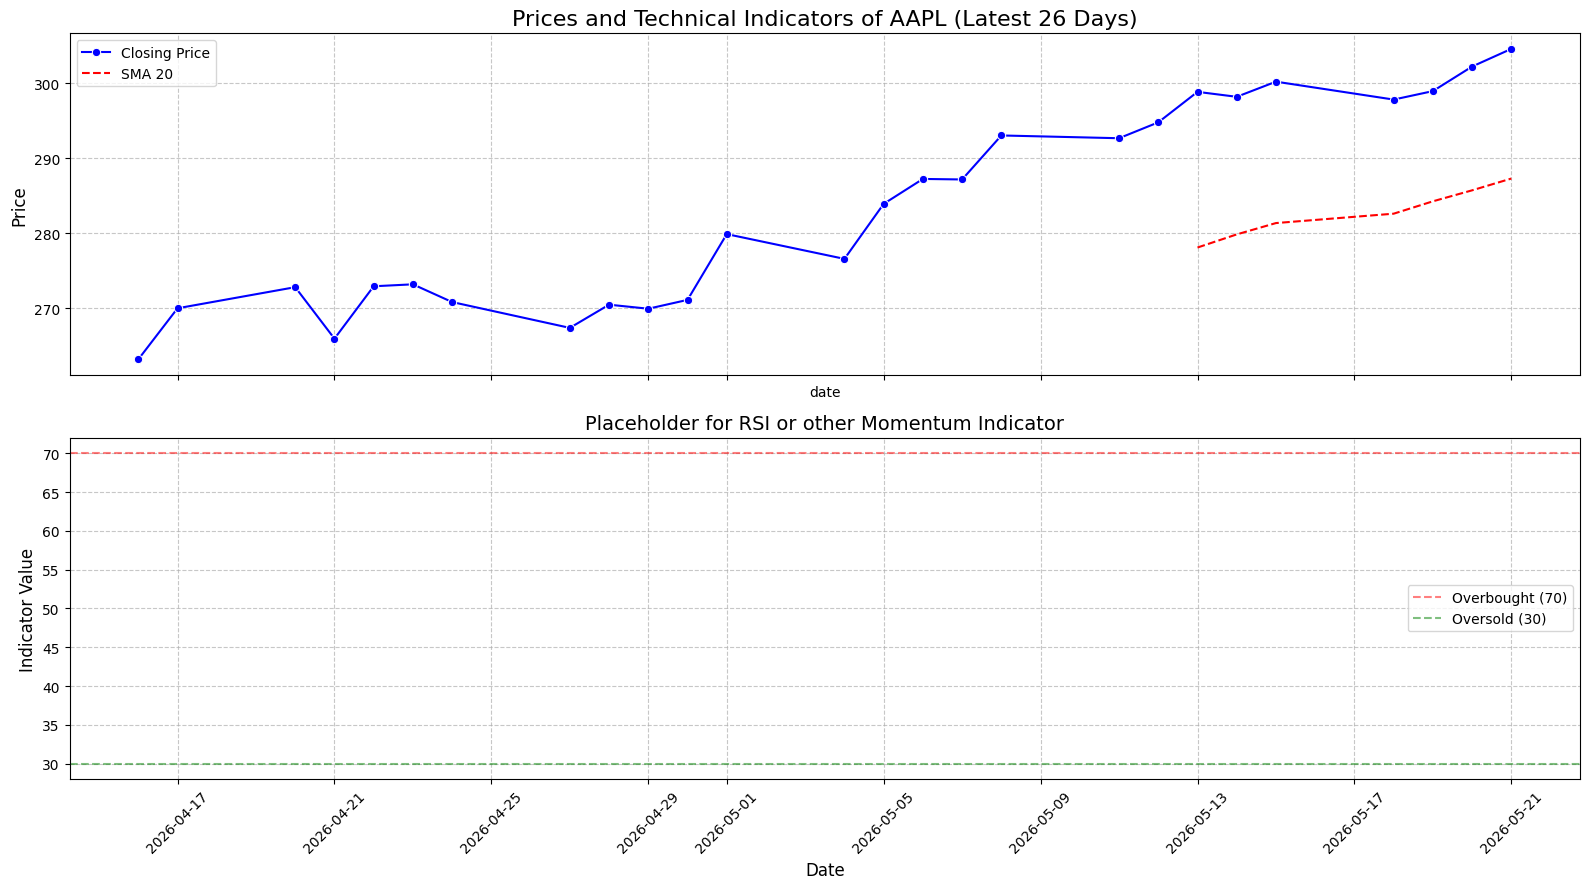

📈 Advanced Indicators Chart generated for AAPL.

================ ADVANCED ANALYSIS AGENT'S VERDICT ==================
```json
{
"ticker": "AAPL",
"analysis_period_days": 26,
"technical_indicators_suggested": ["RSI_14", "SMA_10", "SMA_20", "Volume_Analysis"],
"technical_analysis_report": "Over the last 26 available trading days, Apple (AAPL) has shown a clear upward trend in its closing prices, moving from approximately 263.16 to 304.61. This sustained increase indicates robust bullish momentum in the short to medium term.\n\n**Simple Moving Average (SMA) Analysis**: If calculated, a shorter-period SMA (e.g., 10-day SMA) would likely be positioned above a longer-period SMA (e.g., 20-day SMA), reflecting the ongoing bullish momentum. This pattern typically confirms a strong uptrend, with any short-term SMA crossovers above the longer-term SMA serving as a reinforcing buy signal.\n\n**Relative Strength Index (RSI) Analysis**: Given the consistent price appreciation, the 14-period Relativ

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os


class AgentTraderPlatform:
    def __init__(self):
       # Cliente unificado del nuevo SDK google-genai
        self.client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))
        self.model_name = "gemini-2.5-flash"
        self._cache = {}
        # Define the cache file path using BASE_PATH (assumed to be global)
        self._cache_file_path = os.path.join(BASE_PATH, 'agent_cache.json')
        self._load_cache() # Load cache on initialization

    def _load_cache(self):
        if os.path.exists(self._cache_file_path):
            try:
                with open(self._cache_file_path, 'r', encoding='utf-8') as f:
                    self._cache = json.load(f)
                print(f"Cache loaded from {self._cache_file_path}")
            except json.JSONDecodeError as e:
                print(f"Error decoding cache file: {e}. Starting with empty cache.")
                self._cache = {}
            except Exception as e:
                print(f"Error loading cache file: {e}. Starting with empty cache.")
                self._cache = {}
        else:
            print("No cache file found. Starting with empty cache.")

    def _save_cache(self):
        try:
            # Ensure the directory exists
            os.makedirs(os.path.dirname(self._cache_file_path), exist_ok=True)
            with open(self._cache_file_path, 'w', encoding='utf-8') as f:
                json.dump(self._cache, f, indent=4)
            print(f"Cache saved to {self._cache_file_path}")
        except Exception as e:
            print(f"Error saving cache file: {e}")

    def analyze_asset(self, ticker: str) -> str:
        print(f"🤖 Basic AI agent initiating technical analysis for: {ticker}...")

        cache_key = f"basic_analysis_{ticker}"
        if cache_key in self._cache:
            print(f"Retrieving basic analysis for {ticker} from cache.")
            return self._cache[cache_key]

        prompt_usuario = f"""
        Perform an analytical analysis of the asset with ticker '{ticker}'.
        Consult its last 15 price records in the 'fact_historical_prices' table
        to evaluate its recent behavior, including price, volume, and volatility.
        Generate your investment recommendation and create a line chart that visualizes this data.
        """

        try:
            # In the new SDK, system tools and instructions are passed
            # within the GenerateContentConfig object
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=prompt_usuario,
                config=types.GenerateContentConfig(
                    system_instruction=TRADER_AGENT_PROMPT,
                    tools=[query_trader_database]
                    # response_mime_type="application/json"  # Removed this line as it's unsupported with tools
                )
            )
            agent_verdict_json_str = response.text
            self._cache[cache_key] = agent_verdict_json_str # Cache the result
            self._save_cache() # Save cache after modification

            # --- Start: Integrated Chart Generation ---
            try:
                clean_agent_verdict = agent_verdict_json_str.replace('```json', '').replace('```', '').strip()
                agent_output = json.loads(clean_agent_verdict)

                ticker_to_plot = agent_output.get('ticker', ticker) # Use the ticker from agent output, fallback to input
                # The agent specifies "last 15 records", so we query for that.
                sql_query = f"SELECT date, open, high, low, close FROM fact_historical_prices WHERE ticker = '{ticker_to_plot}' ORDER BY date DESC LIMIT 15"
                data_json = query_trader_database(sql_query)

                if data_json and data_json != '[]': # Check if data_json is not empty or an empty list
                    df_plot = pd.read_json(StringIO(data_json))

                    # Ensure date is in datetime format and sort chronologically
                    df_plot['date'] = pd.to_datetime(df_plot['date'])
                    df_plot = df_plot.sort_values('date').reset_index(drop=True)

                    # Calculate daily range for volatility visualization
                    df_plot['daily_range'] = df_plot['high'] - df_plot['low']

                    # Create the plot as suggested by the agent
                    plt.figure(figsize=(14, 7))
                    sns.lineplot(x='date', y='close', data=df_plot, marker='o', color='blue', label='Closing Price')

                    # Add shaded area for volatility (daily high-low range)
                    plt.fill_between(df_plot['date'], df_plot['low'], df_plot['high'], color='skyblue', alpha=0.3, label='Daily Price Range (Volatility)')

                    plt.title(f'{ticker_to_plot} Closing Prices and Daily Volatility (Last 15 Days)', fontsize=16)
                    plt.xlabel('Date', fontsize=12)
                    plt.ylabel('Price', fontsize=12)
                    plt.xticks(rotation=45)
                    plt.grid(True, linestyle='--', alpha=0.7)
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
                    print(f"📈 Chart generated for {ticker_to_plot}.")
                else:
                    print(f"⚠️ No historical data available to plot for {ticker_to_plot}.")
            except json.JSONDecodeError:
                print(f"⚠️ Could not parse agent's JSON output for plotting: {clean_agent_verdict}")
            except Exception as plot_e:
                print(f"❌ Error during chart generation: {plot_e}")
            # --- End: Integrated Chart Generation ---

            return agent_verdict_json_str
        except Exception as e:
            # If agent execution itself fails
            return f"❌ Error in agent execution: {str(e)}"

    def analyze_advanced_indicators(self, ticker: str) -> str:
        print(f"🤖 Advanced AI agent initiating advanced indicator analysis for basic: {ticker}...")

        cache_key = f"advanced_analysis_{ticker}"
        if cache_key in self._cache:
            print(f"Retrieving advanced analysis for {ticker} from cache.")
            return self._cache[cache_key]

        prompt_usuario_advanced = f"""
        Perform a detailed analysis of the asset with ticker '{ticker}'.
        Consult its last 50 price records in the 'fact_historical_prices' table
        to evaluate its performance using technical indicators such as the RSI, SMA, and volume.
        Generate your investment recommendation and create a line chart that visualizes this data.
        """
        try:
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=prompt_usuario_advanced,
                config=types.GenerateContentConfig(
                    system_instruction=ADVANCED_TRADER_AGENT_PROMPT,
                    tools=[query_trader_database]
                )
            )
            agent_output_json_str = response.text
            self._cache[cache_key] = agent_output_json_str # Cache the result
            self._save_cache() # Save cache after modification

            clean_agent_output = agent_output_json_str.replace('```json', '').replace('```', '').strip()
            agent_output = json.loads(clean_agent_output)

            ticker_to_plot = agent_output.get('ticker', ticker)
            analysis_period = agent_output.get('analysis_period_days', 50)

            # Consult data to graph and calculate indicators
            sql_query = f"SELECT date, open, high, low, close, volume FROM fact_historical_prices WHERE ticker = '{ticker_to_plot}' ORDER BY date DESC LIMIT {analysis_period}"
            data_json = query_trader_database(sql_query)

            if data_json and data_json != '[]':
                df_plot = pd.read_json(StringIO(data_json))
                df_plot['date'] = pd.to_datetime(df_plot['date'])
                df_plot = df_plot.sort_values('date').reset_index(drop=True)

                # --- Home: Generation of Technical Indicators ---
                # Example: Calculate Simple Moving Average (SMA) for 20 periods
                if not df_plot.empty and len(df_plot) >= 20: # Ensure you have enough data for SMA_20
                    df_plot['SMA_20'] = df_plot['close'].rolling(window=20).mean()
                # For RSI,
                if not df_plot.empty and len(df_plot) >= 14:
                  delta = df_plot['close'].diff()
                  gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
                  loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

                  rs = gain / loss
                  df_plot['rsi_14'] = 100 - (100 / (1 + rs))
                # --- End: Generation of Technical Indicators ---

                # --- Home: Generating Charts for Advanced Indicators ---
                plt.figure(figsize=(16, 9))

                # Subchart 1: Price and SMA
                ax1 = plt.subplot(2, 1, 1) # 2 rows, 1 column, first chart
                sns.lineplot(x='date', y='close', data=df_plot, marker='o', color='blue', label='Closing Price', ax=ax1)
                if 'SMA_20' in df_plot.columns:
                    sns.lineplot(x='date', y='SMA_20', data=df_plot, color='red', label='SMA 20', linestyle='--', ax=ax1)
                ax1.set_title(f'Prices and Technical Indicators of {ticker_to_plot} (Latest {analysis_period} Days)', fontsize=16)
                ax1.set_ylabel('Price', fontsize=12)
                ax1.legend()
                ax1.grid(True, linestyle='--', alpha=0.7)
                plt.setp(ax1.get_xticklabels(), visible=False) # Hide X-axis labels for the chart above

                # Placeholder for RSI or other indicator on a separate subchart
                ax2 = plt.subplot(2, 1, 2, sharex=ax1) # Share X-axis with the first graph
                # If RSI were calculated: sns.lineplot(x='date', y='RSI', data=df_plot, color='green', label='RSI', ax=ax2)
                ax2.axhline(70, linestyle='--', alpha=0.5, color='red')
                ax2.axhline(30, linestyle='--', alpha=0.5, color='green')
                ax2.set_title('Placeholder for RSI or other Momentum Indicator', fontsize=14)
                ax2.set_ylabel('Indicator Value', fontsize=12)
                ax2.set_xlabel('Date', fontsize=12)
                ax2.grid(True, linestyle='--', alpha=0.7)
                ax2.legend(['Overbought (70)', 'Oversold (30)']) # Placeholder Legend
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

                print(f"📈 Advanced Indicators Chart generated for {ticker_to_plot}.")
                # --- End: Generating Charts for Advanced Indicators ---
            else:
                print(f"⚠️ No historical data is available for graphing. {ticker_to_plot} for advanced analysis.")

            return agent_output_json_str
        except json.JSONDecodeError:
            print(f"⚠️ The JSON output from the agent could not be analyzed for advanced analysis.: {clean_agent_output}")
        except Exception as e:
            return f"❌ Error in the execution of the advanced analysis agent: {str(e)}"

    def manage_portfolio_decision(self, ticker: str) -> str:
        print(f"🧠 Portfolio Manager Agent synthesizing decisions for: {ticker}...")

        # Get recommendations from sub-agents
        trader_report = self.analyze_asset(ticker)
        advanced_trader_report = self.analyze_advanced_indicators(ticker)

        trader_recommendation = "N/A"
        trader_justification = "N/A"
        advanced_trader_recommendation = "N/A"
        advanced_trader_justification = "N/A"

        try:
            # Try to parse the basic trader report
            clean_trader_report = trader_report.replace('```json', '').replace('```', '').strip()
            trader_output = json.loads(clean_trader_report)
            trader_recommendation = trader_output.get('recommendation', 'N/A')
            trader_justification = trader_output.get('technical_justification', 'N/A')
        except json.JSONDecodeError:
            print(f"⚠️ Could not parse TRADER_AGENT_PROMPT output: {trader_report}")
        except Exception as e:
            print(f"❌ Error processing TRADER_AGENT_PROMPT output: {str(e)}")

        try:
            # Try to parse the advanced trader report
            clean_advanced_trader_report = advanced_trader_report.replace('```json', '').replace('```', '').strip()
            advanced_trader_output = json.loads(clean_advanced_trader_report)
            advanced_trader_recommendation = advanced_trader_output.get('recommendation', 'N/A')
            advanced_trader_justification = advanced_trader_output.get('justification', 'N/A')
        except json.JSONDecodeError:
            print(f"⚠️ Could not parse ADVANCED_TRADER_AGENT_PROMPT output: {advanced_trader_report}")
        except Exception as e:
            print(f"❌ Error processing ADVANCED_TRADER_AGENT_PROMPT output: {str(e)}")

        # Construct the prompt for the Portfolio Manager Agent
        portfolio_manager_prompt_user = f"""
        Analyze the following reports for ticker '{ticker}':

        TRADER_AGENT_PROMPT Report:
        Recommendation: {trader_recommendation}
        Justification: {trader_justification}

        ADVANCED_TRADER_AGENT_PROMPT Report:
        Recommendation: {advanced_trader_recommendation}
        Justification: {advanced_trader_justification}

        Based on these inputs, provide a final consolidated investment decision.
        """

        try:
            response = self.client.models.generate_content(
                model=self.model_name,
                contents=portfolio_manager_prompt_user,
                config=types.GenerateContentConfig(
                    system_instruction=PORTFOLIO_MANAGER_AGENT_PROMPT,
                    # No tools are directly used by the Portfolio Manager as it synthesizes other agents' outputs
                )
            )
            portfolio_decision_json_str = response.text
            clean_portfolio_decision = portfolio_decision_json_str.replace('```json', '').replace('```', '').strip()

            # Print the decision immediately before returning
            print("\n================ PORTFOLIO MANAGER AGENT'S DECISION ==================")
            print(clean_portfolio_decision)
            print("======================================================================")

            return clean_portfolio_decision
        except Exception as e:
            return f"❌ Error in Portfolio Manager Agent execution: {str(e)}"


# =====================================================================
# 4. SPRINT 4 EXECUTION AND TESTING
# =====================================================================
# Instantiate the modern trading agent
agente = AgentTraderPlatform()

# We tested with an existing asset in your DuckDB (e.g., ECOPETROL or AAPL)
ticker_a_probar = "AAPL"

agent_report = agente.analyze_asset(ticker_a_probar)

print("\n================AI AGENT'S VERDICT ==================")
print(agent_report)
print("======================================================================")

print("\n================ TESTING NEW ADVANCED ANALYTICS AGENT ==================")
advanced_agent_report = agente.analyze_advanced_indicators(ticker_a_probar)
print("\n================ ADVANCED ANALYSIS AGENT'S VERDICT ==================")
print(advanced_agent_report)
print("======================================================================")

# Test the new Portfolio Manager Agent
portfolio_decision = agente.manage_portfolio_decision(ticker_a_probar)


**create README**

In [ ]:
%%writefile README.md

# Trading Multi-Agent (v1)

An end-to-end Multi-Agent AI Trading Platform designed to extract financial market data, build a structured relational data store using DuckDB, and deploy an intelligent, autonomous AI Multi-Agent powered by Gemini 2.5 Flash to perform technical analysis, query data via tool use (function calling), and generate structured quantitative trading recommendations.

## 📌 Project Architecture & Data Flow

The platform follows a modern **Medallion Architecture** coupled with an **Multi-Agent Layer**:

1. **Bronze Layer (Raw Storage):** Connects to the Yahoo Finance API (`yfinance`) to execute hybrid extraction of both local Colombian Stock Exchange (BVC) assets (e.g., `ECOPETROL.CO`, `ISA.CO`) and major international equities (e.g., `AAPL`, `TSLA`, `NVDA`). Data is safely archived in its raw semi-structured CSV form within a persistent Google Drive Data Lake.
2. **Silver Layer (Structured Relational Store):** Utilizes **DuckDB** to build a high-performance analytical database. Raw CSV index structures are parsed, schema types are enforced, and data is normalized into an idempotent relational model (`dim_assets` and `fact_historical_prices`) using robust `INSERT OR REPLACE` transactions.
3. **Multi-Agent Layer (Intelligence Hub):** Deploys a **Gemini 2.5 Flash** Multi-agent using the modern `google-genai` SDK. Equipped with native Tool Calling (Function Calling), the Multi-agent autonomously determines when and how to generate optimized SQL queries against the DuckDB Silver Layer, analyzes short-term trends, and outputs deterministic financial decisions.

---

## 🛠️ Tech Stack

* **Core AI Engine:** Google GenAI SDK (`google-genai`), `gemini-2.5-flash` (with strict JSON response schemas and system instruction constraints).
* **Database & Analytical Engine:** DuckDB (OLAP-optimized, fast vectorized execution engine, embedded persistence).
* **Data Processing & Engineering:** Pandas, NumPy, Python 3.12.
* **Financial Extraction:** Yahoo Finance API (`yfinance`).
* **Storage / Environment:** Google Colab, Google Drive (Persistent Data Lake Storage).
* **Visualization:** Matplotlib, Seaborn.

---

## 📂 Project Structure & Database Schema

### Relational Model Design

#### 1. `dim_assets` (Dimension Table)
Stores descriptive metadata for all monitored financial tokens.
* `ticker` (VARCHAR, Primary Key) - Cleaned ticker handle.
* `asset_name` (VARCHAR) - Full name of the company or equity.
* `market` (VARCHAR) - Market categorization (`BVC` for Colombian market, `GLOBAL` for international equities).
* `currency` (VARCHAR) - Trading currency (`COP`, `USD`).

#### 2. `fact_historical_prices` (Fact Table)
Stores structured granular pricing history.
* `ticker` (VARCHAR, Primary Key / Foreign Key)
* `date` (DATE, Primary Key) - Trading date calendar indicator.
* `open` (DOUBLE) - Opening price.
* `high` (DOUBLE) - Daily session high.
* `low` (DOUBLE) - Daily session low.
* `close` (DOUBLE) - Final session close price.
* `adj_close` (DOUBLE) - Adjusted close price for dividends/splits.
* `volume` (BIGINT) - Volume of shares traded.
* `ingestion_timestamp` (TIMESTAMP) - Audit tracking indicator for incremental loads.

---

## 🚀 Step-by-Step Setup Guide

### 1. Persistent Storage Setup
Ensure your Google Drive is mounted within Google Colab to preserve extracted raw data and the DuckDB analytical binary file:
```python
from google.colab import drive
import os

drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/Trading_Agent_POCv1"
os.makedirs(os.path.join(BASE_PATH, "data", "raw"), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "db"), exist_ok=True))

Writing README.md
